In [1]:
import numpy as np
import matplotlib.pyplot as plt

Gegevens : De te ontwerpen nok moet volgende heffing kunnen realiseren :

    van 45° tot 100° : +40 mm
    van 180° tot 210° : -15 mm
    van 210° tot 260° : -25 mm 
We hebben de transitie op 210° meer geleidelijk gemaakt door deze te verplaatsen naar 216.6° dit zorgt er voor dat de jerk overgang geen probleem veroorzaakt

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 15 kg en 0.076, terwijl het mechanisme volgende statische krachten moet uitoefenen:

    van 45° tot 180° : een konstante druk-kracht van 400 N
    van 180° tot 215° : een konstante trek-kracht van 160 N
    van 215° tot 240° : een lineair afnemende trek-kracht van 200 N tot 0 N 

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.5 sec. 

## Parameters



Bewegingswetten :
1 = stilstand ; 2 = 3de-graads polynoom ; 3 = harmonisch ;
4 = cycloïde ; 5 = 5de-graads polynoom ; 6 = 7de-graads polynoom


In [2]:
# ============================================================================
#  PARAMETERS — pas hier alles aan
# ============================================================================

# ---- Simulatie-resolutie -------------------------------------------------
dtheta = 0.01          # hoekstap [deg]

# ---- Bewegingssegmenten --------------------------------------------------
# Eén segment per regel: (startangle, endangle, startlift, endlift, motionlaw)
# motionlaw: 1=dwell, 2=3rd poly, 3=harmonisch, 4=cycloïde, 5=5th poly, 6=7th poly

startangle1, endangle1, startlift1, endlift1, motionlaw1 =   0,  45,  0,  0, 1   # stilstand
startangle2, endangle2, startlift2, endlift2, motionlaw2 =  45, 100,  0, 40, 4  # opwaarts +40 mm  
startangle3, endangle3, startlift3, endlift3, motionlaw3 = 100, 180, 40, 40, 1   # stilstand op 40 mm
startangle4, endangle4, startlift4, endlift4, motionlaw4 = 180, 216.6, 40, 25, 4   # neerwaarts -15 mm 
startangle5, endangle5, startlift5, endlift5, motionlaw5 = 216.6, 260, 25,  0, 4   # neerwaarts -25 mm 
startangle6, endangle6, startlift6, endlift6, motionlaw6 = 260, 360,  0,  0, 1   # stilstand op 0 mm

# afgeleide hoekspans (voor de Kloomok-Muffley analyses verderop):
theta_seg1 = endangle1 - startangle1
theta_seg2 = endangle2 - startangle2
theta_seg3 = endangle3 - startangle3
theta_seg4 = endangle4 - startangle4
theta_seg5 = endangle5 - startangle5
theta_seg6 = endangle6 - startangle6

# ---- Belastingssegmenten -------------------------------------------------
# positief = drukkracht, negatief = trekkracht
startangleload1, endangleload1, startload1, endload1 =  45, 180,  400,  400   # constante drukkracht 400 N
startangleload2, endangleload2, startload2, endload2 = 180, 215, -160, -160   # constante trekkracht 160 N
startangleload3, endangleload3, startload3, endload3 = 215, 240, -200,    0   # lineair afnemende trekkracht

# ---- Dynamische gegevens van de volger -----------------------------------
mass        = 15           # equivalente massa van de volger [kg]
damping     = 0.076        # dempingsconstante [-]

cycle_time  =  0.5      # cyclustijd [s] hoeveel seconeden duurt één volledige rotatie van de nokkenas?
rpm         = 60 / cycle_time   # 120 rpm

# ---- Nokontwerp — geometrie ----------------------------------------------
R0              = 130   # steekcirkel-straal  [mm]   (gekozen na Kloomok-Muffley analyse)
follower_radius = 30    # rolstraal volger    [mm]   (ruim onder ρ_min-grens)
base_radius     = R0 - follower_radius   # 100 mm
exc             = 0.0   # excentriciteit      [mm]   (centrisch)

# ---- Veerontwerp ---------------------------------------------------------
spring_constant = 20    # veerstijfheid       [N/mm]   --- ITERATIEF AANPASSEN
spring_preload  = 325   # voorspankracht      [N]      --- ITERATIEF AANPASSEN

# ---- Vliegwiel-ontwerp ---------------------------------------------------
K          = 0.05    # fluctuatiecoëfficiënt    [-]    (5 % is industriestandaard)
rho_staal  = 7800    # dichtheid staal          [kg/m³]
R_o        = 0.25    # buitenstraal velg        [m]
R_i        = 0.20    # binnenstraal velg        [m]
t_motor    = 2     # tijd om vliegwiel op toerental te krijgen [s]
# ---- Zoekruimtes voor R0- en ρ-analyse -----------------------------------
R0_min, R0_max, R0_delta = 0, 150, 0.1   # zoek R0 van 0 tot 150 mm in stappen van 0.1 mm


In [3]:
# Allocatie van simulatie-arrays (gebruikt door de analyse-cellen hieronder).
# Alle waarden komen uit het parameter-blok hierboven.

theta_deg      = np.arange(0, 360, dtheta)
theta          = theta_deg * np.pi / 180
lift           = np.zeros(len(theta))
vel            = np.zeros(len(theta))
vel_deg        = np.zeros(len(theta))
acc            = np.zeros(len(theta))
acc_deg        = np.zeros(len(theta))
ext_load       = np.zeros(len(theta))
pressure_angle = np.zeros(len(theta))

# zoekruimtes voor R0-/ρ-analyse:
R0_vec    = np.arange(R0_min, R0_max, R0_delta)
alpha_max = np.zeros_like(R0_vec)

beta_vec = np.arange(1, 360, 0.1)
rho_min  = np.zeros_like(beta_vec)


In [4]:
from scipy.optimize import fsolve
import numpy as np
#vind de optimale  hoek om Jerk continue te maken.

L4 = 40 - 25   # = 15 mm (lift of segment 4, positive value)
L5 = 25 - 0    # = 25 mm (lift of segment 5, positive value)
total_angle = 260 - 180  # = 80°

# Solve for beta4 where L4/beta4³ = L5/beta5³
f = lambda b: L4/b**3 - L5/(total_angle - b)**3
b4_optimal = fsolve(f, 30)[0]

print(f"optimal split angle: {180 + b4_optimal:.1f}°")
print(f"beta4 = {b4_optimal:.1f}°, beta5 = {total_angle - b4_optimal:.1f}°")
print(f"check: L4/beta4³ = {L4/b4_optimal**3:.6f}, L5/beta5³ = {L5/(total_angle-b4_optimal)**3:.6f}")

optimal split angle: 216.6°
beta4 = 36.6°, beta5 = 43.4°
check: L4/beta4³ = 0.000306, L5/beta5³ = 0.000306


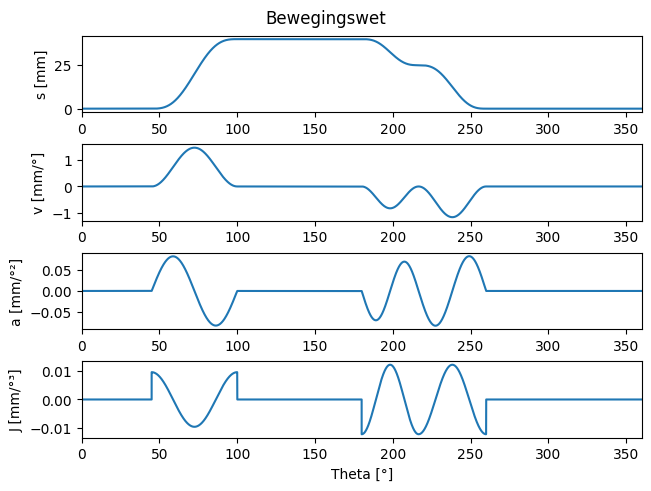

In [5]:
jerk_deg = np.zeros(len(theta))


def addMotionSegment(startangle, endangle, startlift, endlift, motionlaw, dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index), endpoint=False)  

    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)
        jerk_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (-12)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2
        jerk_deg[start_index:end_index] = L / beta**3 * (-np.pi**3 / 2) * np.sin(np.pi * x)

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (4 * np.pi**2) * np.cos(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (360 * x**2 - 360 * x + 60)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
        jerk_deg[start_index:end_index] = L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 420 * x)

    vel = vel_deg * 180 / np.pi
    acc = acc_deg * (180 / np.pi)**2

    return lift, vel_deg, acc_deg, jerk_deg, vel, acc


def plotMotionLaw(t, lift, vel, acc, jerk):
    fig1, ax1 = plt.subplots(nrows=4, ncols=1, constrained_layout=True)
    fig1.suptitle("Bewegingswet")

    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("s [mm]")
    ax1[0].set_xlim([0, 360])

    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("v [mm/°]")
    ax1[1].set_xlim([0, 360])

    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("a [mm/°²]")
    ax1[2].set_xlim([0, 360])

    ax1[3].plot(t, jerk)
    ax1[3].set_ylabel("J [mm/°³]")
    ax1[3].set_xlabel('Theta [°]')
    ax1[3].set_xlim([0, 360])


# Add all six segments to the motion law:
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle1, endangle1, startlift1, endlift1, motionlaw1, dtheta)
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle2, endangle2, startlift2, endlift2, motionlaw2, dtheta)
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle3, endangle3, startlift3, endlift3, motionlaw3, dtheta)
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle4, endangle4, startlift4, endlift4, motionlaw4, dtheta)
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle5, endangle5, startlift5, endlift5, motionlaw5, dtheta)
lift, vel_deg, acc_deg, jerk_deg, vel, acc = addMotionSegment(startangle6, endangle6, startlift6, endlift6, motionlaw6, dtheta)


# Plot the motion law
plotMotionLaw(theta_deg, lift, vel_deg, acc_deg, jerk_deg)
plt.show()
idx_180 = int(180 / dtheta)


hoogste jerk komt voor in het segment dat de kleinste hoek heeft in verhouding tot zijn lift. 
op de rand bij 210° gebeurt een sprong dit is door de overgang van 1 beweging direct in een andere.
om dit optelossen heb ik de overgang meer geleidelijk gemaakt door 216.6° te nemen ipv 210°

In [6]:
# utility functions for external load   (ongewijzigd, externe belasting)

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [°]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')

In [7]:
# utility functions for cam profile design (with eccentricity = 0!) (ongewijzigd, wiskundige hulpfuncties)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (°)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [8]:
# utility functions for pressure angle (ongewijzigd, definities voor drukhoek)

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [°]')
    plt.ylabel('Pressure angle [°]')
    plt.xlim([0,360])

In [9]:
# utility functions for curvature radius (ongewijzigd, pure definities)

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [°]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [°]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [°]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [°]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')


### Ontwerp van minimale steekcirkel $R_0$

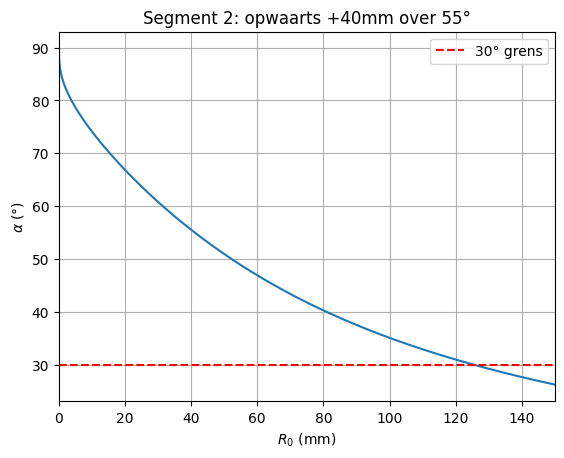

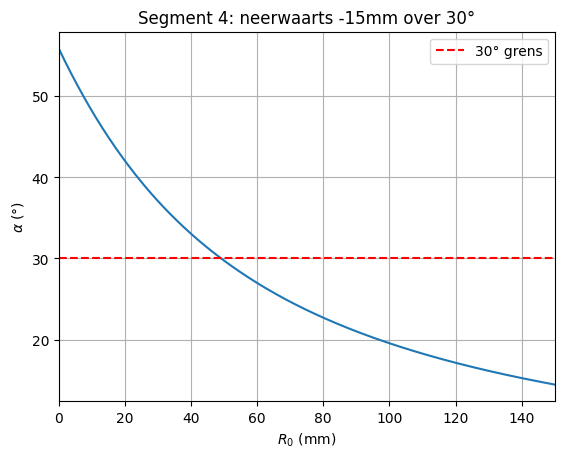

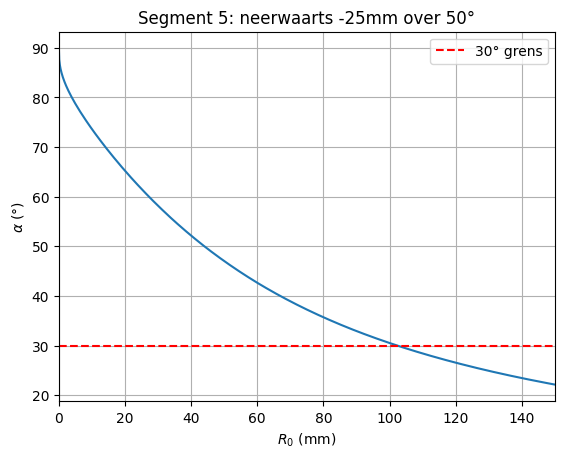

In [10]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [°]')
    ax1[2].set_xlim([0,360])
#segment 1: stilstand op 40 mm over 25°
# segment 2: opwaarts +40 mm over 55°
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 2: opwaarts +40mm over 55°')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (°)')
plt.axhline(y=30, color='r', linestyle='--', label='30° grens')
plt.xlim([0, 150])
plt.legend()
plt.show()
#segment 3: stilstand op 40 mm over 30°
# segment 4: neerwaarts -15 mm over 30°
Kloomok_Muffley_R0(theta_seg4,startlift4,endlift4,motionlaw4)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 4: neerwaarts -15mm over 30°')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (°)')
plt.axhline(y=30, color='r', linestyle='--', label='30° grens')
plt.xlim([0, 150])
plt.legend()
plt.show()

# segment 5: neerwaarts -25 mm over 50°
Kloomok_Muffley_R0(theta_seg5,startlift5,endlift5,motionlaw5)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 5: neerwaarts -25mm over 50°')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (°)')
plt.axhline(y=30, color='r', linestyle='--', label='30° grens')
plt.xlim([0, 150])
plt.legend()
plt.show()

Uit bovenstaande figuren is te zien dat 
Segment 2 : kruist de 30°-lijn bij ongeveer 130 mm → $ R_0 ≥130 $


Segment 4 : kruist bij ongeveer 65 mm → $ R_0≥65R_0 $

Segment 5 : kruist bij ongeveer 85 mm → $R_0≥85 $


Segment 2 is dus bepaalend 



Op basis van de Kloomok-Muffley analyse hierboven kiezen we **R₀ = 130 mm** (zie parameter-blok bovenaan).

### Ontwerp van straal $R_r$ van de volger

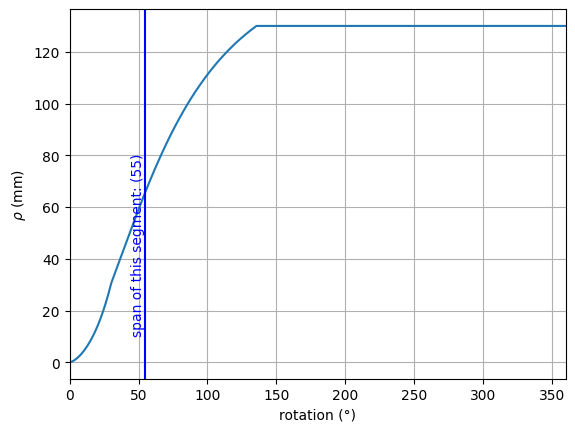

Segment 2 (+40mm/55°)      rho_min=  65.9 mm 


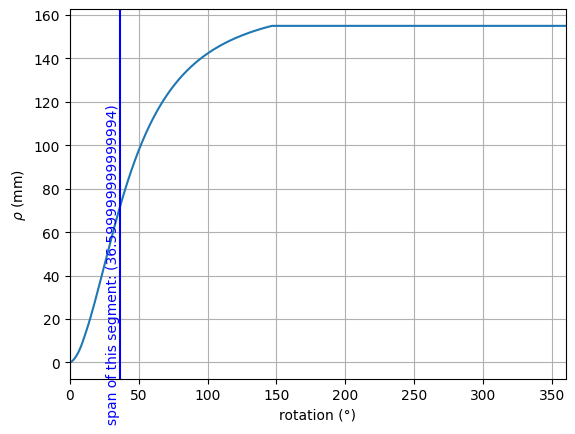

Segment 4 (-15mm/36.6°)    rho_min=  72.1 mm 


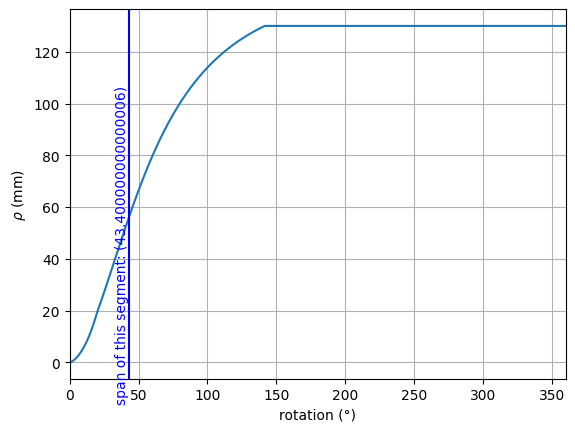

Segment 5 (-25mm/43.4°)    rho_min=  56.6 mm 


In [11]:
# compute R_r for all segments:



for naam, span, s0, s1, wet in [
    ("Segment 2 (+40mm/55°)",   theta_seg2, startlift2, endlift2, motionlaw2),
    ("Segment 4 (-15mm/36.6°)", theta_seg4, startlift4, endlift4, motionlaw4),
    ("Segment 5 (-25mm/43.4°)", theta_seg5, startlift5, endlift5, motionlaw5),
]:
    Kloomok_Muffley_follower_radius(R0, span, s0, s1, wet)
    idx = np.argmin(np.abs(beta_vec - span))
    rho_op_span = rho_min[idx]

    print(f"{naam:25s}  rho_min={rho_op_span:6.1f} mm ")



De kleinste van de drie is segment 4, dit is de maatgevende waarde, rolstraal moet dus kleiner zijn dan 56.6mm.
Hier wordt $ R_r = 30 mm $ genomen voor zelfs met afrondingsfouten en juist resultaat te bekomen.  

We kiezen **r_volger = 30 mm**, ruim onder de ρ_min-grens (zie parameter-blok bovenaan). Hieruit volgt de basisstraal Rb = R₀ − r_volger = 100 mm.

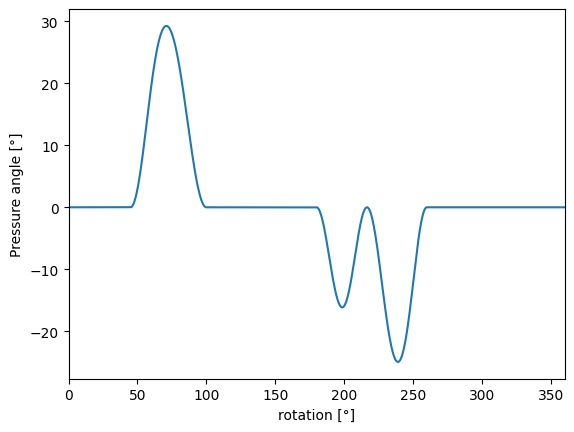

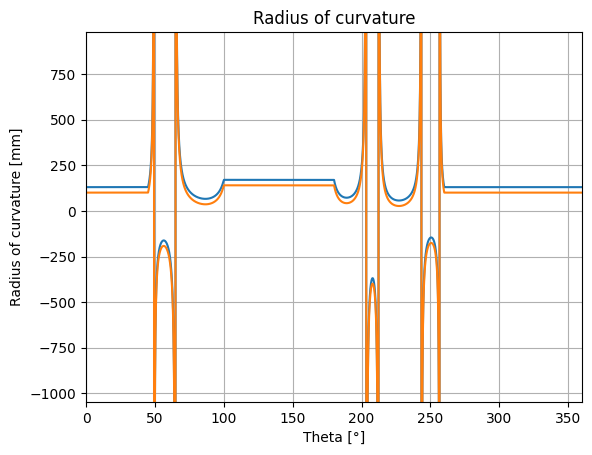

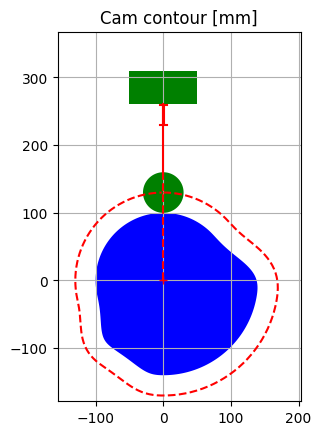

In [12]:
# --- Drukhoek, kromtestraal en nokprofiel ---------------------------------
# (parameters R0, base_radius, follower_radius, exc komen uit het parameter-blok bovenaan.)

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel, exc, base_radius, follower_radius, lift)
plotPressureAngle(theta_deg, pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius, follower_radius, exc, theta, lift, vel, acc)
plotRadiusCurvature(theta_deg, roc_pitch, roc_cam)

# Plot the cam contour
plotCamContour(base_radius, follower_radius, exc, theta, lift, pressure_angle, dtheta)


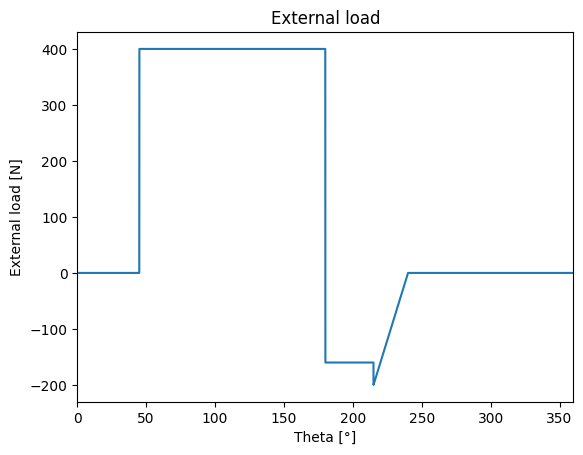

In [13]:
ext_load = addLoadSegment(startangleload1, endangleload1, startload1, endload1, dtheta)
ext_load = addLoadSegment(startangleload2, endangleload2, startload2, endload2, dtheta)
ext_load = addLoadSegment(startangleload3, endangleload3, startload3, endload3, dtheta)

plotExternalLoad(theta_deg, ext_load)

Minimum normaalskracht: 30.9 N  (moet > 0 zijn)


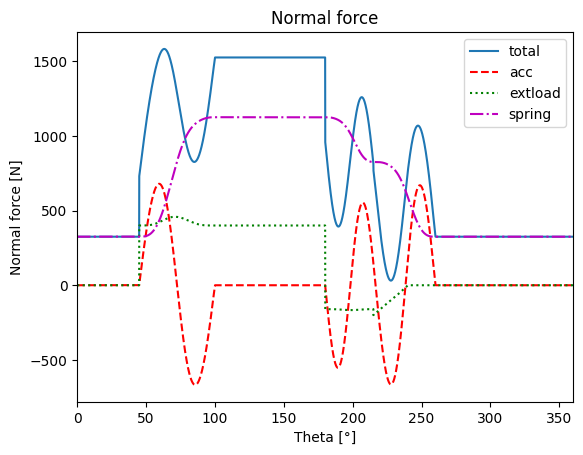

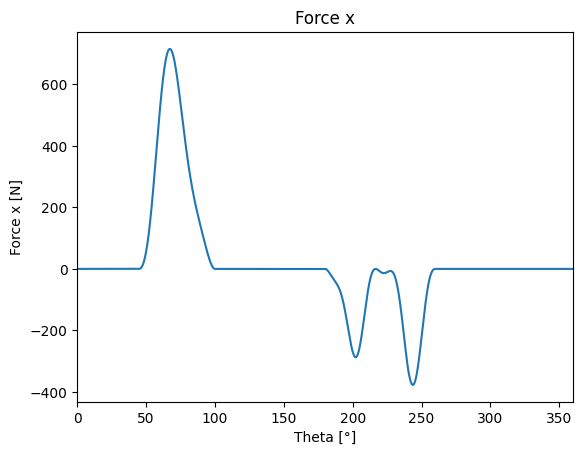

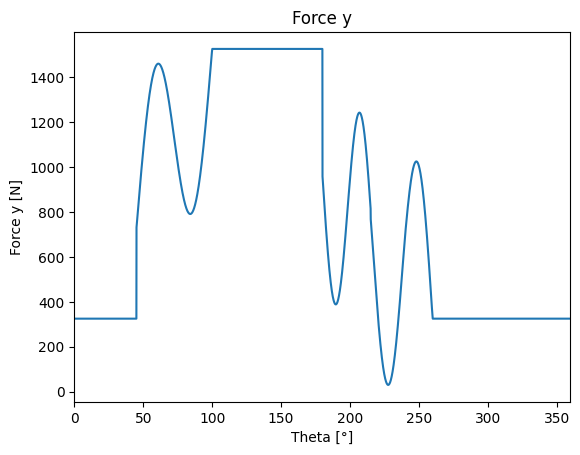

In [14]:
# --- Veer-ontwerp & krachtenanalyse ---------------------------------------
# (mass, spring_constant, spring_preload, rpm komen uit het parameter-blok bovenaan.)

# Calculate forces
[normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring,
 force_x, force_y] = calculateForce(rpm, lift, spring_constant, spring_preload,
                                    pressure_angle, ext_load, mass, acc)

# Plot forces
plotForces(theta_deg, normalforce_tot, normalforce_acc, normalforce_load,
           normalforce_spring, force_x, force_y)

# Controleer: normalforce_tot mag NERGENS negatief zijn!
print(f'Minimum normaalskracht: {normalforce_tot.min():.1f} N  (moet > 0 zijn)')


### Krachten- en vermogensanalyse van de nok

Het aandrijfkoppel van de nok volgt uit de vermogensbalans (geen wrijving):

$$M_{cam}(\theta) = N(\theta)\cos(\alpha) \cdot \frac{dS}{d\theta} = \left[F_{ext} + (F_{v0} + k_v S) + m\omega^2\frac{d^2S}{d\theta^2}\right] \cdot \frac{dS}{d\theta}$$

met $\frac{dS}{d\theta}$ in m/rad. Het aandrijfvermogen is dan $P(\theta) = M_{cam}(\theta)\cdot\omega$.

Het vermogen dat de nok doorgeeft moet gelijk zijn aan het vermogen dat de motor levert


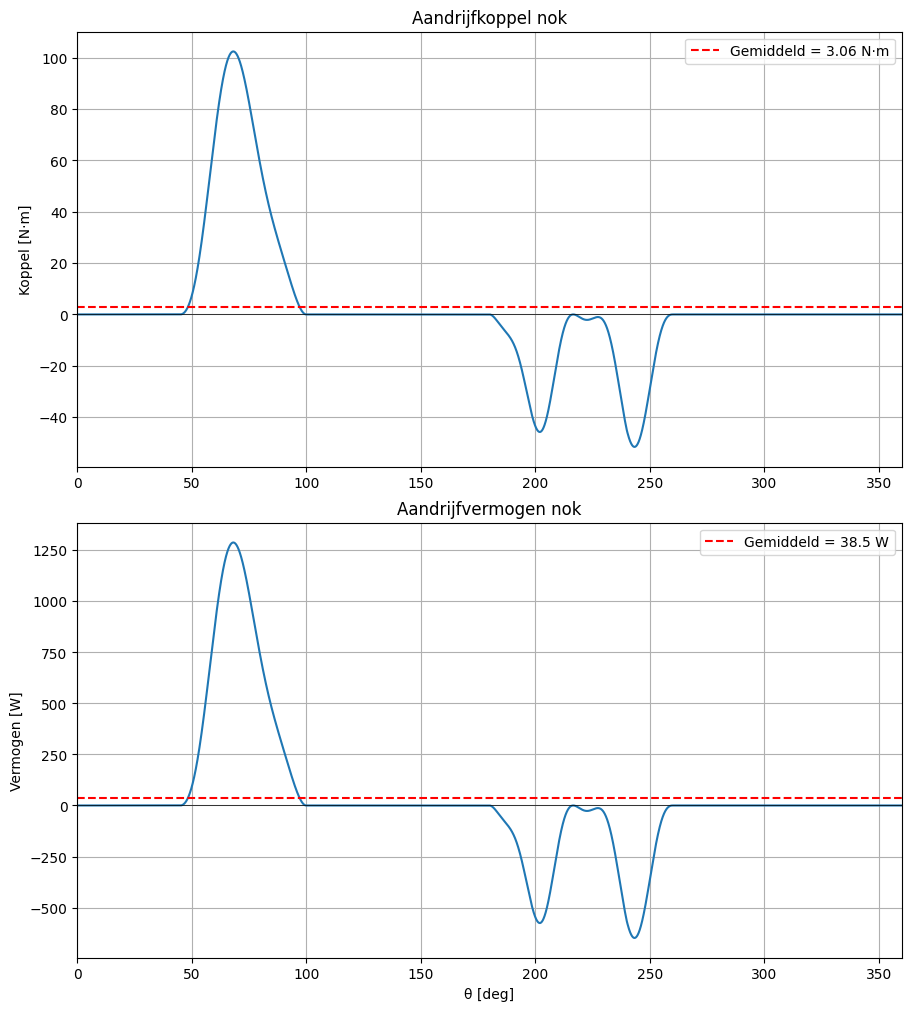

Rotatiesnelheid:          n  = 120.0 rpm  →  ω = 12.566 rad/s
Gemiddeld aandrijfkoppel: M_av  = 3.060 N·m
Gemiddeld aandrijfvermogen: P_av  = 38.46 W
Piek aandrijfkoppel:      M_piek = 102.496 N·m
Piek aandrijfvermogen:    P_piek = 1288.01 W


In [15]:
# vermogensanalyse

omega_rad = rpm * 2 * np.pi / 60  # rad/s



# Krachten op de volger in de bewegingsrichting [N]
F_spring  = spring_preload + spring_constant * lift          # veerkracht [N]
F_inertia = mass * (acc / 1000) * omega_rad**2           # inertiekracht [N]
F_net     = ext_load + F_spring + F_inertia                  # totale kracht die de nok moet leveren [N], gravitatie wordt hier verwaarloosd.

# Aandrijfkoppel van de nok [N·m]  (vel_rad/1000 converteert mm/rad → m/rad)
M_cam = F_net * (vel / 1000)

# Aandrijfvermogen [W]
P_cam = M_cam * omega_rad

# Gemiddelde waarden
M_av = np.mean(M_cam)
P_av = M_av * omega_rad

# Plots
fig, axes = plt.subplots(2, 1, constrained_layout=True, figsize=(9, 10))



axes[0].plot(theta_deg, M_cam)
axes[0].axhline(M_av, color='r', linestyle='--', label=f'Gemiddeld = {M_av:.2f} N·m')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('Koppel [N·m]')
axes[0].set_title('Aandrijfkoppel nok')
axes[0].legend()
axes[0].set_xlim([0, 360])
axes[0].grid(True)

axes[1].plot(theta_deg, P_cam)
axes[1].axhline(P_av, color='r', linestyle='--', label=f'Gemiddeld = {P_av:.1f} W')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('Vermogen [W]')
axes[1].set_title('Aandrijfvermogen nok')
axes[1].legend()
axes[1].set_xlim([0, 360])
axes[1].grid(True)
axes[1].set_xlabel('θ [deg]')

plt.show()

print(f'Rotatiesnelheid:          n  = {rpm} rpm  →  ω = {omega_rad:.3f} rad/s')
print(f'Gemiddeld aandrijfkoppel: M_av  = {M_av:.3f} N·m')
print(f'Gemiddeld aandrijfvermogen: P_av  = {P_av:.2f} W')
print(f'Piek aandrijfkoppel:      M_piek = {M_cam.max():.3f} N·m')
print(f'Piek aandrijfvermogen:    P_piek = {P_cam.max():.2f} W')

### Ontwerp van het vliegwiel

De snelheidsvariatie van de nokas wordt veroorzaakt door het verschil tussen het momentane aandrijfkoppel $M_{cam}(\theta)$ en het gemiddelde lastkoppel $M_{av}$. Het **maximale arbeidssurplus** $A_{max}$ bepaalt de benodigde vliegwiel-inertie:

$$A_{max} = \int_{\theta_m}^{\theta_M}(M_{cam} - M_{av})\,d\theta = \frac{1}{2}I(\omega_M^2 - \omega_m^2) = I\,K\,\omega_{av}^2$$

met fluctuatiecoëfficiënt $K = \dfrac{\omega_M - \omega_m}{\omega_{av}}$. Hieruit volgt:

$$I = \frac{A_{max}}{K\,\omega_{av}^2}$$

Maximaal arbeidssurplus:  A_max = 42.2902 J
  θ bij ω_max: 48.4°    θ bij ω_min: 97.0°


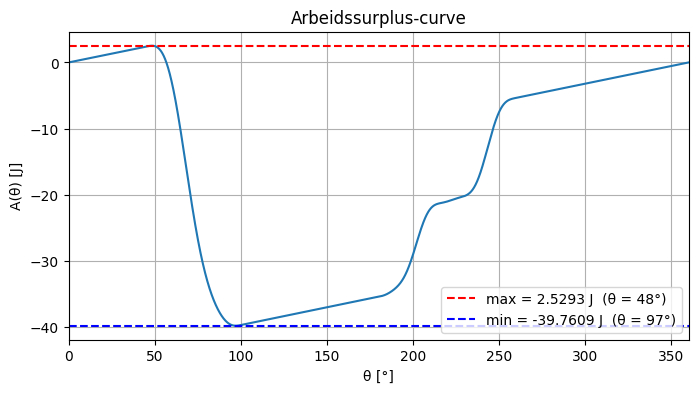


Vliegwiel ontwerp (K = 0.05, ω_av = 12.566 rad/s):
  Benodigde inertie  I = 5.3561 kg·m²
Velg-vliegwiel (staal, R_o = 250 mm, R_i = 200 mm):
  Breedte b = 191.9 mm
  Massa   m = 105.8 kg
  Inertie I = 5.3561 kg·m²  (controle)

Motor-rating:
  Continu vermogen nodig: P ≥ 38.5 W
  Nominaal toerental:     n = 120.0 rpm
  Continu koppel:         M ≥ 3.06 N·m
  Zonder vliegwiel zou piekvermogen 1288 W nodig zijn (factor 33× groter)


In [16]:
# --- Vliegwiel- en motorontwerp -------------------------------------------
# (K, rho_staal, R_o, R_i komen uit het parameter-blok bovenaan.)

dtheta_rad = dtheta * np.pi / 180  # stapgrootte in rad

# Arbeidssurplus-curve: A(θ) = ∫₀^θ (M_av - M_cam) dθ
A_theta = np.cumsum((M_av - M_cam) * dtheta_rad)   # [J]

# Maximaal arbeidssurplus
A_max   = A_theta.max() - A_theta.min()
theta_M = theta_deg[np.argmax(A_theta)]   # hoek bij maximale snelheid
theta_m = theta_deg[np.argmin(A_theta)]   # hoek bij minimale snelheid

print(f'Maximaal arbeidssurplus:  A_max = {A_max:.4f} J')
print(f'  θ bij ω_max: {theta_M:.1f}°    θ bij ω_min: {theta_m:.1f}°')

# Plot arbeidssurplus-curve
plt.figure(figsize=(8, 4))
plt.plot(theta_deg, A_theta)
plt.axhline(A_theta.max(), color='r', linestyle='--',
            label=f'max = {A_theta.max():.4f} J  (θ = {theta_M:.0f}°)')
plt.axhline(A_theta.min(), color='b', linestyle='--',
            label=f'min = {A_theta.min():.4f} J  (θ = {theta_m:.0f}°)')
plt.xlabel('θ [°]')
plt.ylabel('A(θ) [J]')
plt.title('Arbeidssurplus-curve')
plt.legend()
plt.xlim([0, 360])
plt.grid(True)
plt.show()

# --- Vliegwiel-inertie ---
omega_av    = omega_rad
I_vliegwiel = A_max / (K * omega_av**2)

print(f'\nVliegwiel ontwerp (K = {K}, ω_av = {omega_av:.3f} rad/s):')
print(f'  Benodigde inertie  I = {I_vliegwiel:.4f} kg·m²')

# --- Stalen velg-vliegwiel ---
# Velg-vliegwiel: I ≈ m·R_m²
R_m    = (R_o + R_i) / 2
m_velg = I_vliegwiel / R_m**2
b_velg = m_velg / (np.pi * (R_o**2 - R_i**2) * rho_staal)
I_check = m_velg * R_m**2

print(f'Velg-vliegwiel (staal, R_o = {R_o*1000:.0f} mm, R_i = {R_i*1000:.0f} mm):')
print(f'  Breedte b = {b_velg*1000:.1f} mm')
print(f'  Massa   m = {m_velg:.1f} kg')
print(f'  Inertie I = {I_check:.4f} kg·m²  (controle)')

# --- Motor-dimensionering ---
P_motor_continu = abs(P_av)
print(f'\nMotor-rating:')
print(f'  Continu vermogen nodig: P ≥ {P_motor_continu:.1f} W')
print(f'  Nominaal toerental:     n = {rpm} rpm')
print(f'  Continu koppel:         M ≥ {abs(M_av):.2f} N·m')
print(f'  Zonder vliegwiel zou piekvermogen {P_cam.max():.0f} W nodig zijn'
      f' (factor {P_cam.max()/P_motor_continu:.0f}× groter)')


Nokoppervlakte         A   =    43395 mm²
Massacentrum           cx  =   12.90 mm,   cy = -20.52 mm
Excentriciteit         e   =   24.24 mm     <-- dikte-onafhankelijk
Onbalans per m dikte   F/t =    1296 N per meter dikte

Absolute onbalanskracht F = m·e·ω²  bij ω = 12.57 rad/s:
------------------------------------------------
   dikte 10 mm  ->  m =  3.38 kg   F =   13.0 N
   dikte 20 mm  ->  m =  6.77 kg   F =   25.9 N
   dikte 30 mm  ->  m = 10.15 kg   F =   38.9 N


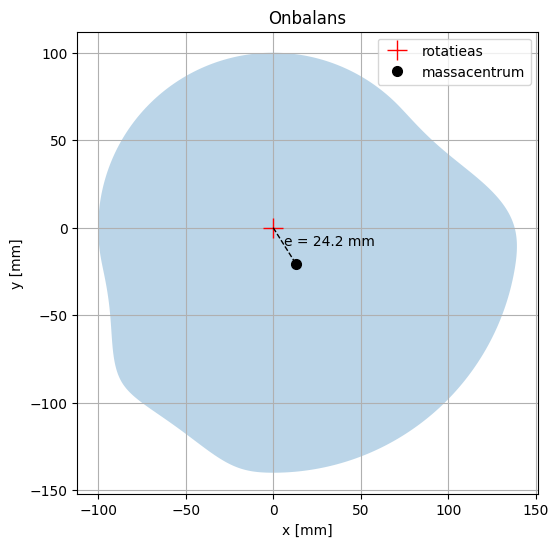

In [17]:
# ============================================================================
#  ONBALANSANALYSE — haalt alles automatisch uit bestaande variabelen
# ============================================================================

omega_rad = rpm * 2 * np.pi / 60   # zelfstandig, voor het geval nog niet gedefinieerd

# ---- Nokprofiel reconstrueren uit bestaande ontwerpvariabelen --------------
d       = np.sqrt((base_radius + follower_radius)**2 - exc**2)
lambda_ = -theta - np.arctan2(exc, d + lift) + np.pi/2
xpitch  = np.cos(lambda_) * np.sqrt((d + lift)**2 + exc**2)
ypitch  = np.sin(lambda_) * np.sqrt((d + lift)**2 + exc**2)
xcam    = xpitch + follower_radius * np.cos(-theta + pressure_angle + 3*np.pi/2)
ycam    = ypitch + follower_radius * np.sin(-theta + pressure_angle + 3*np.pi/2)

# Gesloten polygoon in meters:
xc = np.append(xcam, xcam[0]) / 1000
yc = np.append(ycam, ycam[0]) / 1000
cross = xc[:-1]*yc[1:] - xc[1:]*yc[:-1]

# ---- Oppervlakte, massacentrum, excentriciteit (alle dikte-onafhankelijk) --
A_signed = 0.5 * np.sum(cross)
A        = abs(A_signed)
cx       = (1/(6*A_signed)) * np.sum((xc[:-1] + xc[1:]) * cross)
cy       = (1/(6*A_signed)) * np.sum((yc[:-1] + yc[1:]) * cross)
e        = np.hypot(cx, cy)                       # excentriciteit [m]

# Specifieke onbalans (per meter dikte) — volledig bepaald zonder dikte:
me_per_t = rho_staal * A * e                      # m·e per meter dikte [kg·m/m]
F_per_t  = me_per_t * omega_rad**2                # onbalanskracht per meter dikte [N/m]

print(f'Nokoppervlakte         A   = {A*1e6:8.0f} mm²')
print(f'Massacentrum           cx  = {cx*1000:7.2f} mm,   cy = {cy*1000:.2f} mm')
print(f'Excentriciteit         e   = {e*1000:7.2f} mm     <-- dikte-onafhankelijk')
print(f'Onbalans per m dikte   F/t = {F_per_t:7.0f} N per meter dikte')
print()
print(f'Absolute onbalanskracht F = m·e·ω²  bij ω = {omega_rad:.2f} rad/s:')
print('-' * 48)
for t_mm in [10, 20, 30]:
    t = t_mm / 1000
    m_nok = rho_staal * A * t
    F     = m_nok * e * omega_rad**2
    print(f'   dikte {t_mm:2d} mm  ->  m = {m_nok:5.2f} kg   F = {F:6.1f} N')

# ---- Visualisatie: nok, rotatieas en massacentrum -------------------------
plt.figure(figsize=(6, 6))
plt.fill(xcam, ycam, alpha=0.3)
plt.plot(0, 0, 'r+', markersize=14, label='rotatieas')
plt.plot(cx*1000, cy*1000, 'ko', markersize=7, label='massacentrum')
plt.plot([0, cx*1000], [0, cy*1000], 'k--', lw=1)
plt.annotate(f'e = {e*1000:.1f} mm', (cx*1000/2, cy*1000/2),
             fontsize=10, ha='left')
plt.gca().set_aspect('equal')
plt.grid(True)
plt.legend()
plt.title('Onbalans')
plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
plt.show()

Velg vliegwiel in plaats van schijf vlieg wiel. Voor de zelfde massa en straal heeft een velgvliegwiel dubbel zoveel traagheid. Dit is omdat de massa zich langst de buitenkant bevindt

Onze keuze: een velgvliegwiel met buitendiameter 0,5 m, als we dit als een vol vliegwiel zouden implementeren zou de buiten diameter 1 m zijn,
0,5 m is al best groot 1 m is problematisch groot.

De nok heeft een wisselende belasting, zonder vliegwiel zou het koppel van de motor hard fluctueren.
Dankzij het vliegwiel kan een motor 30 keer kkleiner/ goedkoper worden gekozen.

K is een maat voor hoeveel snelheids fluctuaties je toelaat, wij kiezen voor 5%, dit is een standaard in de industrie.
Voor kleinere K waardes is een groter vliegwiel nodig om de fluctuaties op te vangen.


## Resultatenoverzicht

Beknopte samenvatting van alle ontwerpkeuzes en uitkomsten van het volledige
nok-ontwerp.


                        NOKONTWERP — SAMENVATTING                       

[1] BEWEGINGSPROFIEL
    Cyclustijd               : 0.500 s   (120 rpm)
    Maximale heffing         : 40.0 mm
    Minimale heffing         : 0.0 mm
    Piek snelheid            : 83.3 mm/s
    Piek versnelling         : 273.8 mm/s²

[2] NOKGEOMETRIE
    Steekcirkel              R0 = 130.0 mm
    Basisstraal              Rb = 100.0 mm
    Rolstraal volger         Rr = 30.0 mm
    Excentriciteit            e = 0.0 mm
    Maximale drukhoek         α = 29.23°  (grens 30°)
    Minimale kromtestraal    ρmin = 56.6 mm  (> Rr = 30 mm: ✓)

[3] VEER & NORMAALKRACHT
    Veerstijfheid            k  = 20.00 N/mm
    Voorspankracht           F0 = 325.0 N
    Min. normaalkracht       Nmin = 30.9 N  (✓ > 0)
    Max. normaalkracht       Nmax = 1582.2 N

[4] AANDRIJVING
    Hoeksnelheid             ω  = 12.566 rad/s
    Gemiddeld koppel         Mav  = 3.060 N·m
    Piek koppel              Mpiek = 102.496 N·m
    Gemiddeld vermog

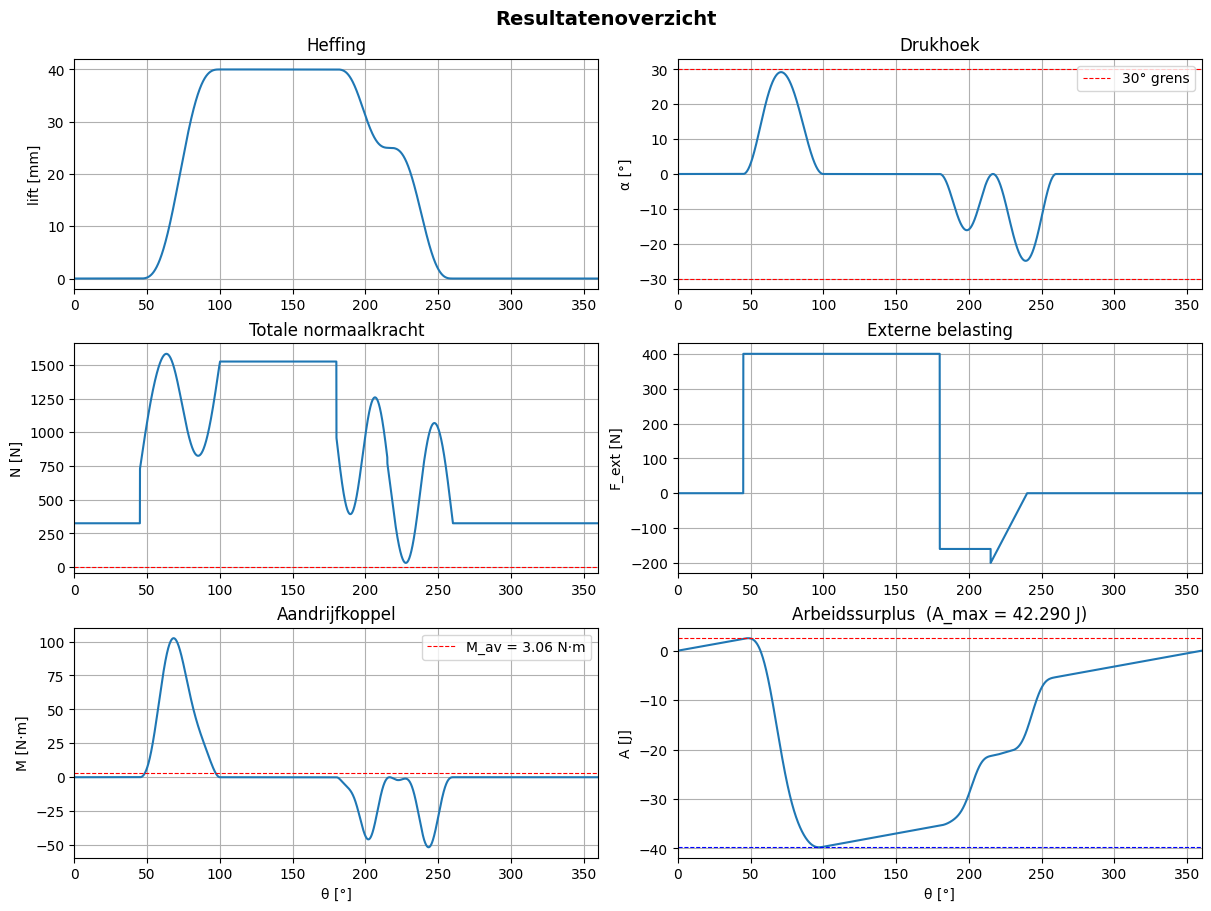

In [18]:
# ============================================================================

print('=' * 72)
print(' NOKONTWERP — SAMENVATTING'.center(72))
print('=' * 72)

# ---- 1. Bewegingsprofiel -------------------------------------------------
print('\n[1] BEWEGINGSPROFIEL')
print(f'    Cyclustijd               : {cycle_time:.3f} s   ({rpm:.0f} rpm)')
print(f'    Maximale heffing         : {lift.max():.1f} mm')
print(f'    Minimale heffing         : {lift.min():.1f} mm')
print(f'    Piek snelheid            : {abs(vel).max():.1f} mm/s')
print(f'    Piek versnelling         : {abs(acc).max():.1f} mm/s²')

# ---- 2. Geometrie van de nok ---------------------------------------------
print('\n[2] NOKGEOMETRIE')
print(f'    Steekcirkel              R0 = {R0:.1f} mm')
print(f'    Basisstraal              Rb = {base_radius:.1f} mm')
print(f'    Rolstraal volger         Rr = {follower_radius:.1f} mm')
print(f'    Excentriciteit            e = {exc:.1f} mm')
print(f'    Maximale drukhoek         α = {abs(pressure_angle).max()*180/np.pi:.2f}°  '
      f'(grens 30°)')
inds = np.where(np.abs(np.diff(roc_pitch) / dtheta) < 1e3)[0]
roc_min = np.min(np.abs(roc_pitch[inds + 1]))
print(f'    Minimale kromtestraal    ρmin = {roc_min:.1f} mm  '
      f'(> Rr = {follower_radius} mm: ✓)')

# ---- 3. Veer & krachten --------------------------------------------------
print('\n[3] VEER & NORMAALKRACHT')
print(f'    Veerstijfheid            k  = {spring_constant:.2f} N/mm')
print(f'    Voorspankracht           F0 = {spring_preload:.1f} N')
print(f'    Min. normaalkracht       Nmin = {normalforce_tot.min():.1f} N  '
      f'({"✓ > 0" if normalforce_tot.min() > 0 else "✗ NEGATIEF!"})')
print(f'    Max. normaalkracht       Nmax = {normalforce_tot.max():.1f} N')

# ---- 4. Aandrijving ------------------------------------------------------
print('\n[4] AANDRIJVING')
print(f'    Hoeksnelheid             ω  = {omega_rad:.3f} rad/s')
print(f'    Gemiddeld koppel         Mav  = {M_av:.3f} N·m')
print(f'    Piek koppel              Mpiek = {M_cam.max():.3f} N·m')
print(f'    Gemiddeld vermogen       Pav  = {P_av:.2f} W')
print(f'    Piek vermogen            Ppiek = {P_cam.max():.1f} W   '
      f'(factor {P_cam.max()/abs(P_av):.0f}× t.o.v. gemiddeld)')

# ---- 5. Vliegwiel & motor -----------------------------------------------
omega_start = omega_rad / t_motor
print('\n[5] VLIEGWIEL & MOTOR')
print(f'    Fluctuatiecoëff.         K  = {K:.3f}')
print(f'    Max. arbeidssurplus      Amax = {A_max:.4f} J')
print(f'    Benodigde inertie        I  = {I_vliegwiel:.4f} kg·m²')
print(f'    Velg (staal, Ro={R_o*1000:.0f} mm / Ri={R_i*1000:.0f} mm):')
print(f'        breedte              b  = {b_velg*1000:.1f} mm')
print(f'        massa                m  = {m_velg:.1f} kg')
print(f'    Motor (continue rating):')
print(f'        toerental            n  = {rpm:.0f} rpm')
print(f'        vermogen             P ≥ {abs(P_av):.1f} W')
print(f'        koppel               M ≥ {abs(M_av):.2f} N·m')
print(f'        Zonder vliegwiel zou piekvermogen {P_cam.max():.0f} W nodig zijn')
print(f'        M_start = {I_vliegwiel * omega_start :.2f} N·m  (koppel nodig om vliegwiel in beweging te krijgen)')





print('=' * 72)

# ---- 6. Visuele samenvatting --------------------------------------------
fig, ax = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('Resultatenoverzicht', fontsize=14, fontweight='bold')

ax[0, 0].plot(theta_deg, lift)
ax[0, 0].set_title('Heffing')
ax[0, 0].set_ylabel('lift [mm]'); ax[0, 0].set_xlim([0, 360]); ax[0, 0].grid(True)

ax[0, 1].plot(theta_deg, pressure_angle * 180 / np.pi)
ax[0, 1].axhline(30, color='r', ls='--', lw=0.8, label='30° grens')
ax[0, 1].axhline(-30, color='r', ls='--', lw=0.8)
ax[0, 1].set_title('Drukhoek')
ax[0, 1].set_ylabel('α [°]'); ax[0, 1].set_xlim([0, 360]); ax[0, 1].grid(True); ax[0, 1].legend()

ax[1, 0].plot(theta_deg, normalforce_tot)
ax[1, 0].axhline(0, color='r', ls='--', lw=0.8)
ax[1, 0].set_title('Totale normaalkracht')
ax[1, 0].set_ylabel('N [N]'); ax[1, 0].set_xlim([0, 360]); ax[1, 0].grid(True)

ax[1, 1].plot(theta_deg, ext_load)
ax[1, 1].set_title('Externe belasting')
ax[1, 1].set_ylabel('F_ext [N]'); ax[1, 1].set_xlim([0, 360]); ax[1, 1].grid(True)

ax[2, 0].plot(theta_deg, M_cam)
ax[2, 0].axhline(M_av, color='r', ls='--', lw=0.8, label=f'M_av = {M_av:.2f} N·m')
ax[2, 0].set_title('Aandrijfkoppel')
ax[2, 0].set_ylabel('M [N·m]'); ax[2, 0].set_xlabel('θ [°]')
ax[2, 0].set_xlim([0, 360]); ax[2, 0].grid(True); ax[2, 0].legend()

ax[2, 1].plot(theta_deg, A_theta)
ax[2, 1].axhline(A_theta.max(), color='r', ls='--', lw=0.8)
ax[2, 1].axhline(A_theta.min(), color='b', ls='--', lw=0.8)
ax[2, 1].set_title(f'Arbeidssurplus  (A_max = {A_max:.3f} J)')
ax[2, 1].set_ylabel('A [J]'); ax[2, 1].set_xlabel('θ [°]')
ax[2, 1].set_xlim([0, 360]); ax[2, 1].grid(True)

plt.show()
